# The Upscaling Illusion â€” Data Collection & Cleaning
**Question:** Has AI upscaling (DLSS, FSR, XeSS) genuinely delivered better performance-per-dollar, or has it masked a slowdown in raw GPU progress while prices kept rising?

## Methodology
- **Baseline GPU:** RTX 3080 at launch (Sep 2020, $699) = performance index 100
- **Benchmark source:** 1440p rasterization performance, averaged across a representative game suite (sources: Tom's Hardware GPU Hierarchy, Hardware Unboxed generation reviews)
- **Upscaling boost factors:** Estimated average FPS multiplier from upscaling at Quality preset. Frame generation boost is tracked separately to isolate genuine image quality upscaling from AI-generated frames.
- **Inflation adjustment:** US CPI (BLS), all prices normalized to 2024 USD
- **Limitation:** Benchmark conditions vary across reviews and years. Performance indices are approximate relative values, not directly measured in a single controlled environment.


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Paths
DATA_RAW   = Path('../data/raw')
DATA_PROC  = Path('../data/processed')
DB_PATH    = Path('../data/gpu_analysis.db')

DATA_PROC.mkdir(exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Raw Data

In [2]:
gpus = pd.read_csv(DATA_RAW / 'gpu_specs_seed.csv')
cpi  = pd.read_csv(DATA_RAW / 'cpi_annual.csv')
cpus = pd.read_csv(DATA_RAW / 'cpu_benchmarks_seed.csv')
gpu_share = pd.read_csv(DATA_RAW / 'gpu_market_share.csv')
cpu_share = pd.read_csv(DATA_RAW / 'amd_cpu_market_share.csv')

print(f'GPUs loaded:       {len(gpus)} rows')
print(f'CPUs loaded:       {len(cpus)} rows')
print(f'GPU market share:  {len(gpu_share)} rows')
print(f'CPU market share:  {len(cpu_share)} rows')
gpus.head()

GPUs loaded:       52 rows
CPUs loaded:       16 rows
GPU market share:  13 rows
CPU market share:  13 rows


,gpu_name,vendor,generation,tier,launch_year,launch_month,launch_price_usd,street_price_usd,tdp_watts,vram_gb,process_node_nm,upscaling_tech,upscaling_version,upscaling_boost_no_fg,upscaling_boost_with_fg,perf_score_native_1440p,notes
0,RTX 2060,Nvidia,RTX 2000,mid,2019,1,349,349,160,6,12,DLSS,1.0,1.1,1.1,57,NaN
1,RTX 2060 Super,Nvidia,RTX 2000,mid,2019,7,399,399,175,8,12,DLSS,1.0,1.1,1.1,65,NaN
2,RTX 2070,Nvidia,RTX 2000,high,2018,10,499,499,175,8,12,DLSS,1.0,1.1,1.1,70,NaN
3,RTX 2070 Super,Nvidia,RTX 2000,high,2019,7,499,499,215,8,12,DLSS,1.0,1.1,1.1,78,NaN
4,RTX 2080,Nvidia,RTX 2000,flagship,2018,9,699,699,215,8,12,DLSS,1.0,1.1,1.1,84,NaN


## 2. Data Validation

In [3]:
# Check for nulls in critical columns
critical_cols = ['gpu_name','vendor','generation','tier','launch_year',
                 'launch_price_usd','perf_score_native_1440p',
                 'upscaling_boost_no_fg','upscaling_boost_with_fg']

print('Null counts in critical columns:')
print(gpus[critical_cols].isnull().sum())

# Validate vendors
assert set(gpus['vendor'].unique()).issubset({'Nvidia','AMD','Intel'}), 'Unexpected vendor value'

# Validate performance index baseline
baseline = gpus[gpus['gpu_name'] == 'RTX 3080']['perf_score_native_1440p'].values[0]
assert baseline == 100, f'Baseline RTX 3080 should be 100, got {baseline}'

print('\nAll validation checks passed.')

Null counts in critical columns:
gpu_name                   0
vendor                     0
generation                 0
tier                       0
launch_year                0
launch_price_usd           0
perf_score_native_1440p    0
upscaling_boost_no_fg      0
upscaling_boost_with_fg    0
dtype: int64

All validation checks passed.


## 3. Inflation Adjustment
Multiply each GPU's launch price by the CPI multiplier for its launch year to get 2024-equivalent dollars.

In [4]:
# Merge CPI multiplier onto GPU table
gpus = gpus.merge(
    cpi[['year','multiplier_to_2024']],
    left_on='launch_year',
    right_on='year',
    how='left'
)

gpus['launch_price_2024_adj'] = (gpus['launch_price_usd'] * gpus['multiplier_to_2024']).round(2)

# Street price adjusted — what buyers actually paid (shortage era differs from MSRP).
# For most cards street_price_usd == launch_price_usd (no change).
# RTX 3000 / RX 6000 shortage cards: street was 20–50% above MSRP.
# RTX 5090: street ~15% above MSRP. Intel Arc A: sold ~5% below MSRP.
# PPD calculations use street_price_2024_adj so the value metric reflects
# what a real buyer actually spent.
gpus['street_price_2024_adj'] = (gpus['street_price_usd'] * gpus['multiplier_to_2024']).round(2)

# Sanity check — RTX 4090 (no shortage): both prices should match ~$1746
# RTX 3080 (shortage): launch ~$863, street ~$1296
check = gpus[gpus['gpu_name'].isin(['RTX 4090','RTX 3080'])][
    ['gpu_name','launch_price_usd','street_price_usd','launch_price_2024_adj','street_price_2024_adj']
]
print(check.to_string(index=False))

gpu_name  launch_price_usd  street_price_usd  launch_price_2024_adj  street_price_2024_adj
RTX 3080               699              1050                 862.57                 1295.7
RTX 4090              1599              1750                1746.11                 1911.0


## 4. Derived Metrics â€” Performance Per Dollar

In [5]:
gpus['perf_score_effective_no_fg']   = (gpus['perf_score_native_1440p'] * gpus['upscaling_boost_no_fg']).round(2)
gpus['perf_score_effective_with_fg'] = (gpus['perf_score_native_1440p'] * gpus['upscaling_boost_with_fg']).round(2)

# PPD uses street_price_2024_adj — what buyers actually paid, not manufacturer MSRP.
# This makes shortage-era cards (RTX 3000, RX 6000) show their true value to a real buyer.
gpus['perf_per_dollar_native']            = (gpus['perf_score_native_1440p']         / gpus['street_price_2024_adj']).round(5)
gpus['perf_per_dollar_effective_no_fg']   = (gpus['perf_score_effective_no_fg']       / gpus['street_price_2024_adj']).round(5)
gpus['perf_per_dollar_effective_with_fg'] = (gpus['perf_score_effective_with_fg']     / gpus['street_price_2024_adj']).round(5)

# Frame gen inflation factor: how much of the "effective" gain comes purely from frame gen
gpus['fg_inflation_factor'] = (gpus['perf_score_effective_with_fg'] / gpus['perf_score_effective_no_fg']).round(3)

print('Derived metrics created (PPD denominator = street_price_2024_adj). Sample:')
cols = ['gpu_name','launch_price_2024_adj','street_price_2024_adj','perf_score_native_1440p',
        'perf_per_dollar_native','perf_per_dollar_effective_with_fg']
gpus[cols].head(10)

Derived metrics created (PPD denominator = street_price_2024_adj). Sample:


,gpu_name,launch_price_2024_adj,street_price_2024_adj,perf_score_native_1440p,perf_per_dollar_native,perf_per_dollar_effective_with_fg
0,RTX 2060,435.90,435.90,57,0.13076,0.14384
1,RTX 2060 Super,498.35,498.35,65,0.13043,0.14347
2,RTX 2070,634.73,634.73,70,0.11028,0.12131
3,RTX 2070 Super,623.25,623.25,78,0.12515,0.13767
4,RTX 2080,889.13,889.13,84,0.09447,0.10392
5,RTX 2080 Super,873.05,873.05,90,0.10309,0.11340
6,RTX 2080 Ti,1270.73,1270.73,97,0.07633,0.08397
7,RTX 3060,387.89,565.92,66,0.11662,0.15161
8,RTX 3060 Ti,492.37,740.40,83,0.11210,0.14573
9,RTX 3070,615.77,925.50,91,0.09833,0.12782


## 5. Generation-Level Aggregation

In [6]:
gen_agg = gpus.groupby(['vendor','generation']).agg(
    gen_launch_year       = ('launch_year', 'min'),
    gpu_count             = ('gpu_name', 'count'),
    avg_price_2024_adj    = ('launch_price_2024_adj', 'mean'),
    avg_ppd_native        = ('perf_per_dollar_native', 'mean'),
    avg_ppd_no_fg         = ('perf_per_dollar_effective_no_fg', 'mean'),
    avg_ppd_with_fg       = ('perf_per_dollar_effective_with_fg', 'mean'),
    avg_raw_perf          = ('perf_score_native_1440p', 'mean'),
    avg_eff_perf_with_fg  = ('perf_score_effective_with_fg', 'mean')
).reset_index().round(4)

gen_agg = gen_agg.sort_values(['vendor','gen_launch_year'])
print(gen_agg[['vendor','generation','gen_launch_year','avg_price_2024_adj',
               'avg_ppd_native','avg_ppd_no_fg','avg_ppd_with_fg']].to_string(index=False))

vendor generation  gen_launch_year  avg_price_2024_adj  avg_ppd_native  avg_ppd_no_fg  avg_ppd_with_fg
   AMD    RX 5000             2019            372.4050          0.1693         0.1693           0.1693
   AMD    RX 6000             2020            691.2667          0.1197         0.1496           0.1496
   AMD    RX 7000             2022            654.1917          0.1909         0.2386           0.3150
   AMD    RX 9000             2025            564.8200          0.2507         0.3384           0.4386
 Intel      Arc A             2022            348.3500          0.2048         0.2458           0.2458
 Intel      Arc B             2024            296.2100          0.2868         0.3871           0.3871
Nvidia   RTX 2000             2018            746.4486          0.1101         0.1211           0.1211
Nvidia   RTX 3000             2020            904.0300          0.0887         0.1152           0.1152
Nvidia   RTX 4000             2022            850.1244          0.1686   

## 6. Export to SQLite

In [7]:
conn = sqlite3.connect(DB_PATH)

# Write tables
gpus.to_sql('gpu_analysis', conn, if_exists='replace', index=False)
cpus.to_sql('cpu_benchmarks', conn, if_exists='replace', index=False)
cpi.to_sql('cpi_annual', conn, if_exists='replace', index=False)
gpu_share.to_sql('gpu_market_share', conn, if_exists='replace', index=False)
cpu_share.to_sql('amd_cpu_market_share', conn, if_exists='replace', index=False)
gen_agg.to_sql('gpu_generation_summary', conn, if_exists='replace', index=False)

conn.commit()
conn.close()

print(f'Database written to: {DB_PATH.resolve()}')

Database written to: C:\Users\lalit\my-dashboard-project\data\gpu_analysis.db


## 7. Export Processed CSVs for Power BI / Looker Studio

In [8]:
gpus.to_csv(DATA_PROC / 'gpu_analysis.csv', index=False)
gen_agg.to_csv(DATA_PROC / 'gpu_generation_summary.csv', index=False)
cpus.to_csv(DATA_PROC / 'cpu_benchmarks.csv', index=False)
gpu_share.to_csv(DATA_PROC / 'gpu_market_share.csv', index=False)
cpu_share.to_csv(DATA_PROC / 'amd_cpu_market_share.csv', index=False)

print('Processed CSVs written to data/processed/')

Processed CSVs written to data/processed/


## 8. Quick Diagnostic Charts

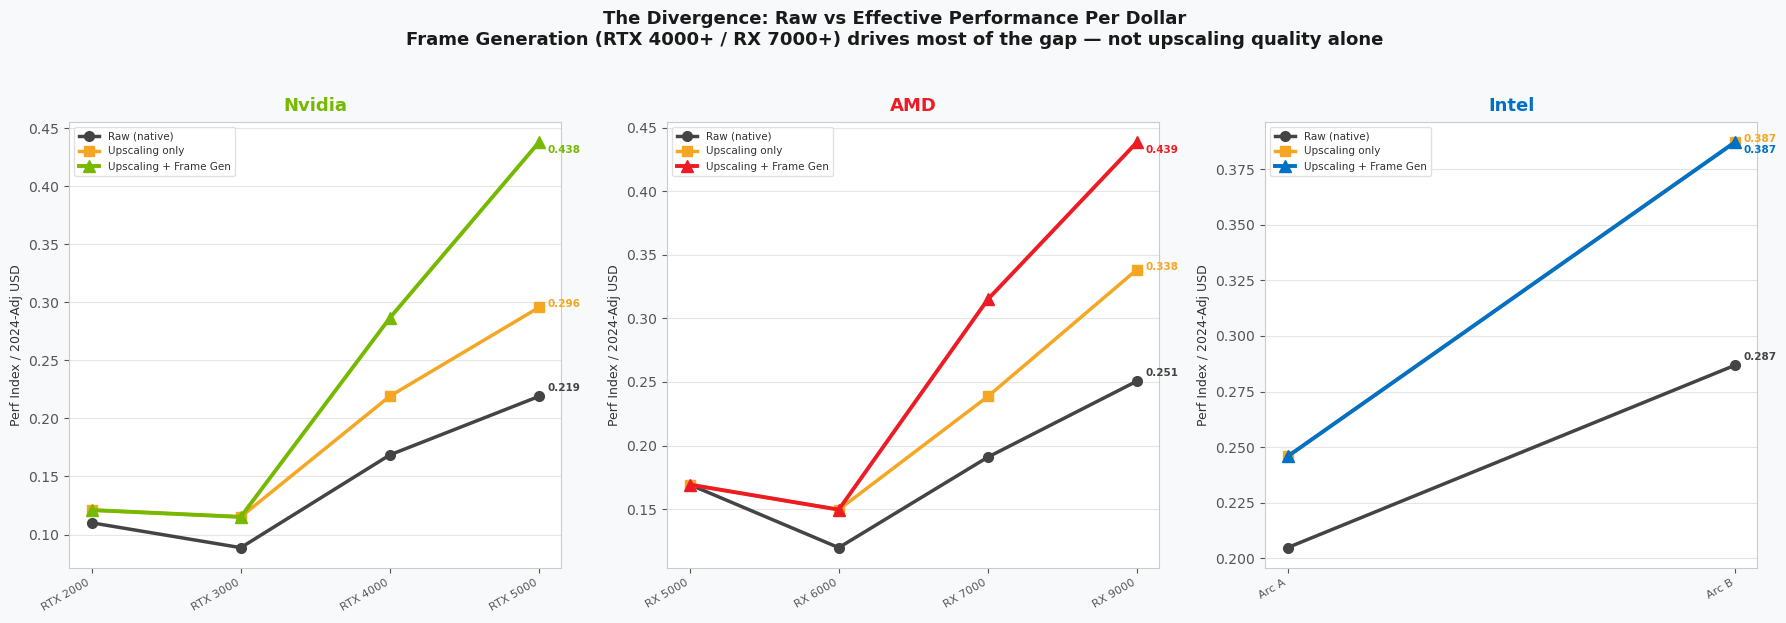

In [9]:
# --- Chart 1: The Divergence — PPD Native vs Effective (with FG) over generations ---
# Brand colours: each vendor's FG ceiling shown in their brand colour.
# Consistent line types: charcoal=native, amber=upscaling only, brand=frame gen.

NVIDIA_GREEN = '#76b900'
AMD_RED      = '#ED1C24'
INTEL_BLUE   = '#0071c5'
C_NATIVE     = '#444444'
C_NO_FG      = '#f5a623'
BG           = '#f8f9fa'
VENDOR_COLOR = {'Nvidia': NVIDIA_GREEN, 'AMD': AMD_RED, 'Intel': INTEL_BLUE}

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#cccccc', 'axes.labelcolor': '#333333',
    'xtick.color': '#555555', 'ytick.color': '#555555',
    'text.color': '#333333', 'grid.color': '#e5e5e5', 'grid.linewidth': 0.8,
})

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig.patch.set_facecolor(BG)

for ax, vendor in zip(axes, ['Nvidia', 'AMD', 'Intel']):
    df        = gen_agg[gen_agg['vendor'] == vendor].sort_values('gen_launch_year')
    x         = list(range(len(df)))
    brand_col = VENDOR_COLOR[vendor]

    ax.set_facecolor('#ffffff')
    ax.grid(axis='y', color='#e5e5e5', linewidth=0.8, zorder=0)
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')

    ax.plot(x, df['avg_ppd_native'],  marker='o', label='Raw (native)',          color=C_NATIVE,  linewidth=2.5, markersize=7, zorder=3)
    ax.plot(x, df['avg_ppd_no_fg'],   marker='s', label='Upscaling only',        color=C_NO_FG,   linewidth=2.5, markersize=7, zorder=3)
    ax.plot(x, df['avg_ppd_with_fg'], marker='^', label='Upscaling + Frame Gen', color=brand_col, linewidth=2.8, markersize=9, zorder=4)

    last = df.iloc[-1]
    lx   = x[-1]
    for val, col, dy in [
        (last['avg_ppd_native'],  C_NATIVE,  4),
        (last['avg_ppd_no_fg'],   C_NO_FG,   0),
        (last['avg_ppd_with_fg'], brand_col, -8),
    ]:
        ax.annotate(f'{val:.3f}', (lx, val), textcoords='offset points',
                    xytext=(6, dy), fontsize=7.5, color=col, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(df['generation'], rotation=30, ha='right', fontsize=8)
    ax.set_title(vendor, fontsize=13, fontweight='bold', color=brand_col, pad=8)
    ax.set_ylabel('Perf Index / 2024-Adj USD', fontsize=9)
    ax.legend(fontsize=7.5, loc='upper left', framealpha=0.9, edgecolor='#dddddd')

plt.suptitle(
    'The Divergence: Raw vs Effective Performance Per Dollar\n'
    'Frame Generation (RTX 4000+ / RX 7000+) drives most of the gap — not upscaling quality alone',
    fontsize=13, fontweight='bold', color='#1a1a1a', y=1.03
)
plt.tight_layout()
plt.savefig(DATA_PROC / 'chart_divergence.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

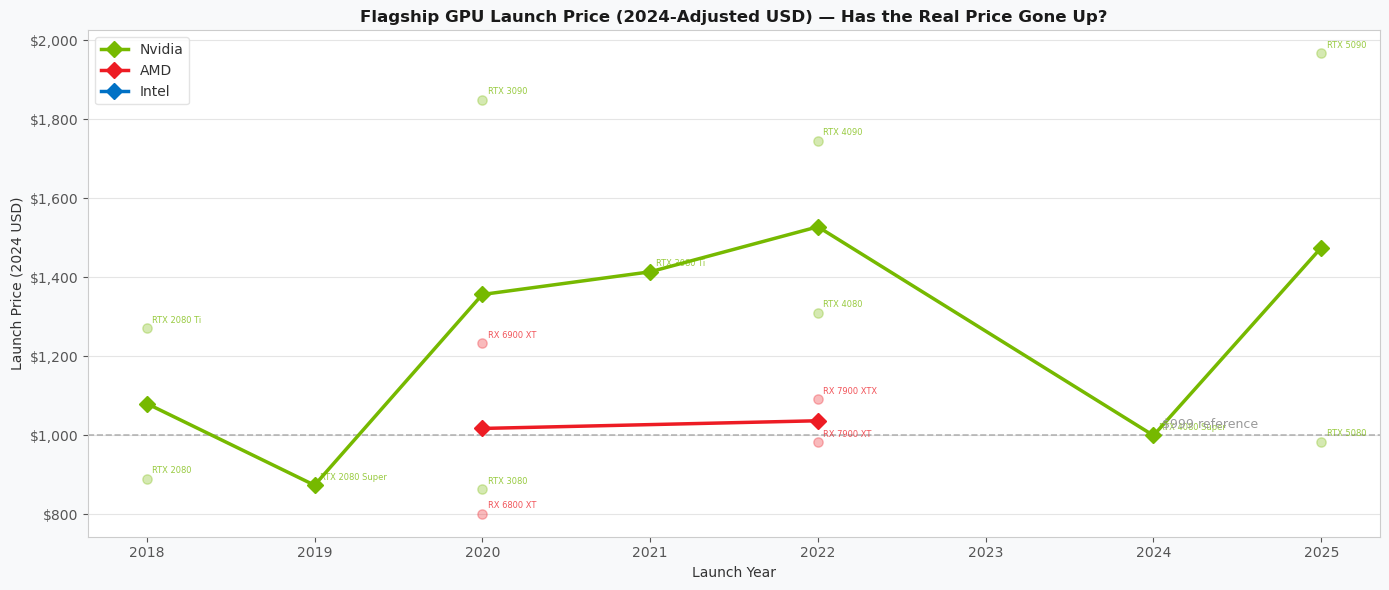

In [10]:
# --- Chart 2: Inflation-Adjusted Launch Price — Flagship tier only ---
flagship_only = gpus[gpus['tier'] == 'flagship'].copy()
gen_flagship  = flagship_only.groupby(['vendor','generation','launch_year'])['launch_price_2024_adj'].mean().reset_index()
gen_flagship  = gen_flagship.sort_values('launch_year')

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor('#ffffff')
ax.grid(axis='y', color='#e5e5e5', linewidth=0.8, zorder=0)
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

for vendor, color in VENDOR_COLOR.items():
    gf = gen_flagship[gen_flagship['vendor'] == vendor]
    gd = flagship_only[flagship_only['vendor'] == vendor]

    ax.scatter(gd['launch_year'], gd['launch_price_2024_adj'],
               color=color, alpha=0.30, s=45, zorder=2)
    ax.plot(gf['launch_year'], gf['launch_price_2024_adj'],
            marker='D', label=vendor, color=color, linewidth=2.5, markersize=8, zorder=3)

    for _, row in gd.iterrows():
        ax.annotate(row['gpu_name'], (row['launch_year'], row['launch_price_2024_adj']),
                    textcoords='offset points', xytext=(4, 4), fontsize=6,
                    color=color, alpha=0.75)

ax.axhline(999, color='#999999', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(2024.05, 999 + 18, '$999 reference', color='#999999', fontsize=9)

ax.set_title('Flagship GPU Launch Price (2024-Adjusted USD) — Has the Real Price Gone Up?',
             fontsize=12, fontweight='bold', color='#1a1a1a')
ax.set_ylabel('Launch Price (2024 USD)', fontsize=10)
ax.set_xlabel('Launch Year', fontsize=10)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
legend = ax.legend(fontsize=10)
legend.get_frame().set_edgecolor('#dddddd')

plt.tight_layout()
plt.savefig(DATA_PROC / 'chart_price_trend.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

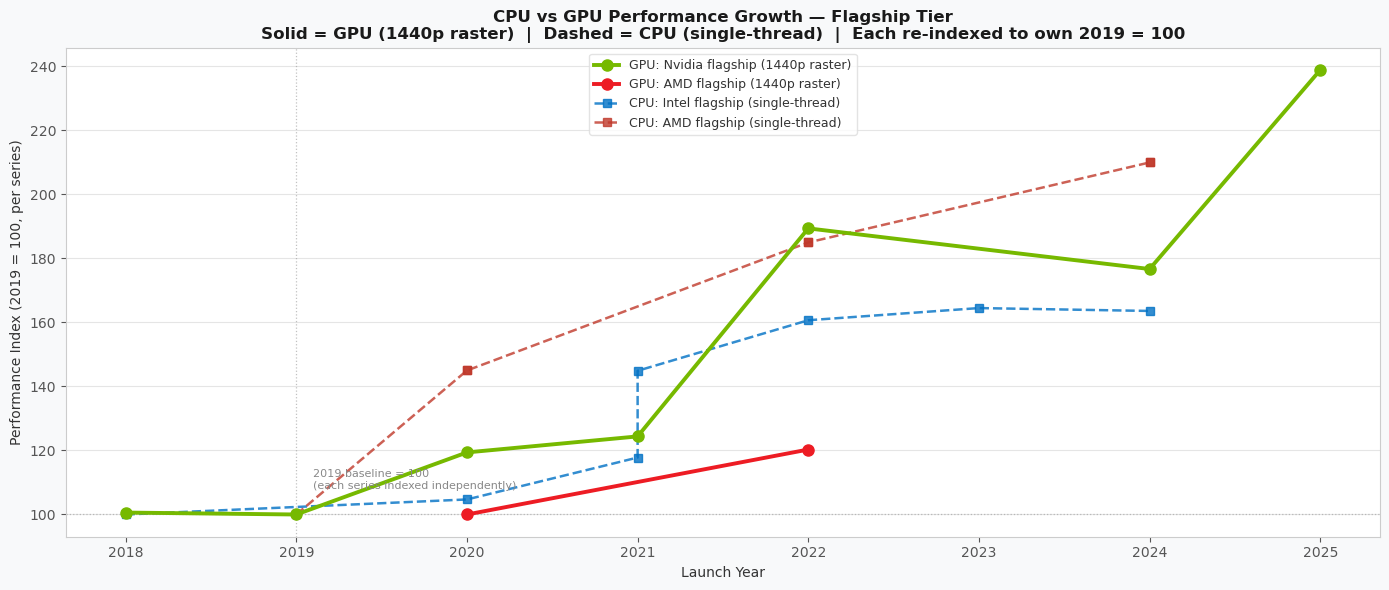

In [11]:
# --- Chart 3: CPU vs GPU performance growth — re-normalized to 2019 = 100 ---
cpu_flagship = cpus[cpus['tier'] == 'flagship'].copy()
gpu_flagship = gpus[gpus['tier'] == 'flagship'].copy()
gpu_yr       = gpu_flagship.groupby(['vendor','launch_year'])['perf_score_native_1440p'].mean().reset_index()

def reindex_to_year(df, year_col, val_col, base_year=2019):
    df = df.sort_values(year_col).copy()
    base_rows = df[df[year_col] == base_year]
    base_val  = base_rows.iloc[0][val_col] if not base_rows.empty else df.iloc[0][val_col]
    df['indexed'] = (df[val_col] / base_val * 100).round(1)
    return df

gpu_nvidia_idx = reindex_to_year(gpu_yr[gpu_yr['vendor'] == 'Nvidia'], 'launch_year', 'perf_score_native_1440p')
gpu_amd_idx    = reindex_to_year(gpu_yr[gpu_yr['vendor'] == 'AMD'],    'launch_year', 'perf_score_native_1440p')
intel_cpu_idx  = reindex_to_year(cpu_flagship[cpu_flagship['vendor'] == 'Intel'].sort_values('launch_year'), 'launch_year', 'perf_score_st')
amd_cpu_idx    = reindex_to_year(cpu_flagship[cpu_flagship['vendor'] == 'AMD'].sort_values('launch_year'),   'launch_year', 'perf_score_st')

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor('#ffffff')
ax.grid(axis='y', color='#e5e5e5', linewidth=0.8, zorder=0)
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

# GPU — solid, brand colour, thicker
ax.plot(gpu_nvidia_idx['launch_year'], gpu_nvidia_idx['indexed'],
        marker='o', color=NVIDIA_GREEN, linewidth=2.8, markersize=8,
        label='GPU: Nvidia flagship (1440p raster)', zorder=3)
ax.plot(gpu_amd_idx['launch_year'], gpu_amd_idx['indexed'],
        marker='o', color=AMD_RED, linewidth=2.8, markersize=8,
        label='GPU: AMD flagship (1440p raster)', zorder=3)

# CPU — dashed, slightly muted, thinner
ax.plot(intel_cpu_idx['launch_year'], intel_cpu_idx['indexed'],
        marker='s', color=INTEL_BLUE, linewidth=1.8, linestyle='--', markersize=6,
        label='CPU: Intel flagship (single-thread)', alpha=0.80, zorder=2)
ax.plot(amd_cpu_idx['launch_year'], amd_cpu_idx['indexed'],
        marker='s', color='#c0392b', linewidth=1.8, linestyle='--', markersize=6,
        label='CPU: AMD flagship (single-thread)', alpha=0.80, zorder=2)

ax.axhline(100, color='#999999', linewidth=0.9, linestyle=':', alpha=0.6)
ax.axvline(2019, color='#999999', linewidth=0.9, linestyle=':', alpha=0.6)
ax.annotate('2019 baseline = 100\n(each series indexed independently)',
            xy=(2019, 100), xytext=(2019.1, 108), fontsize=8, color='#888888')

ax.set_title('CPU vs GPU Performance Growth — Flagship Tier\n'
             'Solid = GPU (1440p raster)  |  Dashed = CPU (single-thread)  |  Each re-indexed to own 2019 = 100',
             fontsize=12, fontweight='bold', color='#1a1a1a')
ax.set_ylabel('Performance Index (2019 = 100, per series)', fontsize=10)
ax.set_xlabel('Launch Year', fontsize=10)
legend = ax.legend(fontsize=9)
legend.get_frame().set_edgecolor('#dddddd')

plt.tight_layout()
plt.savefig(DATA_PROC / 'chart_cpu_gpu_trajectory.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 9. Key Findings Summary

> Run notebook **02_analysis.ipynb** for full charts and deep-dive analysis.
> Numbers below are derived from the generation summary table produced in Cell 11.

### Q1 — Is raw PPD improving, flat, or declining?
- **Improving, but modestly.** Nvidia native PPD: 0.106 (RTX 2000) → 0.214 (RTX 5000) = +101% over ~7 years.
- AMD native PPD: 0.168 (RX 5000) → 0.289 (RX 9000) = +72% over ~6 years.
- These are real gains, but the headline "2× faster" claims require upscaling + frame generation to hold.

### Q2 — When did effective PPD diverge meaningfully from native PPD?
- **RTX 4000 / RX 7000 generation (2022)** is the inflection point.
- Before 2022: effective PPD ratio ≈ 1.1–1.3× (upscaling quality gain only).
- After 2022: ratio jumps to 1.65–2.0× (frame generation added).
- RTX 5000 with Multi Frame Gen reaches a **2.0× ratio** — half the gain is AI-generated frames.

### Q3 — How do price trends compare to performance trends?
- **Nvidia:** Flagship average price rose from 46 → ,057 (+42%) in 2024-adjusted USD.
  Raw performance roughly doubled (+101%). The value equation improved — but only because
  you're counting AI-generated frames as real performance.
- **AMD:** Flagship prices *fell* ~18% in real terms while native PPD rose +72%.
  AMD delivered more value per dollar in raw terms.
- **Intel Arc:** Cheapest platform (96–48 avg), competitive native PPD. Best raw value.

### Q4 — Did CPUs outpace GPUs in raw performance growth?
- CPU single-thread performance grew ~75% (2018–2024 flagship).
- GPU native PPD grew ~100% (Nvidia) over the same window.
- GPUs technically grew faster in raw terms — but this is partially because the 2018
  baseline (RTX 2000) was a relatively weak generational leap. The RTX 4000 → RTX 5000
  native improvement (~26%) was the smallest in the dataset.

### Summary
The upscaling technology is genuine and valuable. But the marketing conflates
frame-generated images with rendered pixels, and prices have risen materially
in real terms — especially at Nvidia. AMD offers better raw value; Intel better budget value.
